<a href="https://colab.research.google.com/github/NaoKB/EML/blob/main/k_brazos/Comparativa.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Comparativa transversal entre familias

Este notebook compara una configuración representativa de cada familia sobre los tres bandidos diseñados. La selección no pretende afirmar que esos hiperparámetros son universalmente óptimos; pretende contrastar comportamientos cualitativos bajo un presupuesto experimental común.

Algoritmos comparados:

- `ε-greedy ε=0.03`
- `UCB1 c=0.70`
- `Softmax τ=0.35`

Se usan las mismas métricas que en los notebooks intrafamilia para mantener coherencia: recompensa media, porcentaje de selección óptima, pseudo-regret acumulado y estadísticas por brazo.

## Preparación del entorno

In [1]:
from pathlib import Path
import sys
import subprocess

REPO_URL = "https://github.com/NaoKB/EML.git"  # Actualizar si se publica en otro repositorio.


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents, Path("/content/EML/k_brazos"), Path("/content/k_brazos")]
    for candidate in candidates:
        if (candidate / "src" / "bandit_experiment.py").exists():
            return candidate
    return None

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    clone_target = Path("/content/EML")
    if not clone_target.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(clone_target)], check=True)
    PROJECT_ROOT = find_project_root()

if PROJECT_ROOT is None:
    raise RuntimeError("No se ha encontrado la carpeta del proyecto con src/bandit_experiment.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: /mnt/data/rev_k/k_brazos


In [2]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

from src.algorithms import EpsilonGreedy, UCB1, Softmax
from src.bandit_experiment import BanditExperiment, REWARDS_NAME, OPTIMAL_NAME, REGRET_NAME, SUMMARY_NAME, ARM_STATS_NAME
from src.plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics, plot_summary_heatmap
from src.scenarios import build_scenarios, scenario_table, describe_bandit

SEED = 2026
STEPS = 500
RUNS = 75
SMOOTH_WINDOW = 31

np.random.seed(SEED)
scenarios = build_scenarios()
display(scenario_table(scenarios).round(4))

,escenario,brazo,distribución,parámetros,E[r],gap,óptimo
0,bernoulli,0,Bernoulli,ArmBernoulli(p=0.041),0.041,0.023,False
1,bernoulli,1,Bernoulli,ArmBernoulli(p=0.048),0.048,0.016,False
2,bernoulli,2,Bernoulli,ArmBernoulli(p=0.052),0.052,0.012,False
3,bernoulli,3,Bernoulli,ArmBernoulli(p=0.055),0.055,0.009,False
4,bernoulli,4,Bernoulli,ArmBernoulli(p=0.058),0.058,0.006,False
5,bernoulli,5,Bernoulli,ArmBernoulli(p=0.06),0.060,0.004,False
6,bernoulli,6,Bernoulli,ArmBernoulli(p=0.064),0.064,0.000,True
7,binomial,0,Binomial,"ArmBinomial(n=80, p=0.085)",6.800,9.360,False
8,binomial,1,Binomial,"ArmBinomial(n=80, p=0.115)",9.200,6.960,False
9,binomial,2,Binomial,"ArmBinomial(n=80, p=0.135)",10.800,5.360,False


## Ejecución del experimento

In [3]:
def algorithm_factory(k):
    return [
        EpsilonGreedy(k, epsilon=0.03),
        UCB1(k, c=0.70),
        Softmax(k, temperature=0.35),
    ]

results, algorithms_by_scenario = BanditExperiment.run_many(
    scenarios,
    algorithm_factory,
    steps=STEPS,
    runs=RUNS,
    seed=SEED + 300,
)

## Resultados por escenario

## Bernoulli: anuncios con CTR bajo

Prueba difícil por baja señal y gaps pequeños; favorece políticas que acumulen evidencia sin sobreexplorar.

```text
Bandit with 7 arms: ArmBernoulli(p=0.041), ArmBernoulli(p=0.048), ArmBernoulli(p=0.052), ArmBernoulli(p=0.055), ArmBernoulli(p=0.058), ArmBernoulli(p=0.06), ArmBernoulli(p=0.064)

Resumen de medias reales usadas solo para evaluación:
  brazo 0: E[r]=0.0410, gap=0.0230
  brazo 1: E[r]=0.0480, gap=0.0160
  brazo 2: E[r]=0.0520, gap=0.0120
  brazo 3: E[r]=0.0550, gap=0.0090
  brazo 4: E[r]=0.0580, gap=0.0060
  brazo 5: E[r]=0.0600, gap=0.0040
  brazo 6: E[r]=0.0640, gap=0.0000 <- óptimo
```

,algoritmo,recompensa_media_total,recompensa_media_último_20%,regret_final,% óptimo_final,% óptimo_último_20%,% tiradas_brazo_óptimo
0,UCB1 c=0.7,0.0551,0.0536,4.7472,21.3333,14.6000,14.7147
1,Softmax τ=0.35,0.0549,0.0549,4.9173,13.3333,14.7600,15.0000
2,ε-greedy ε=0.03,0.0478,0.0461,7.8794,14.6667,13.9733,10.8827


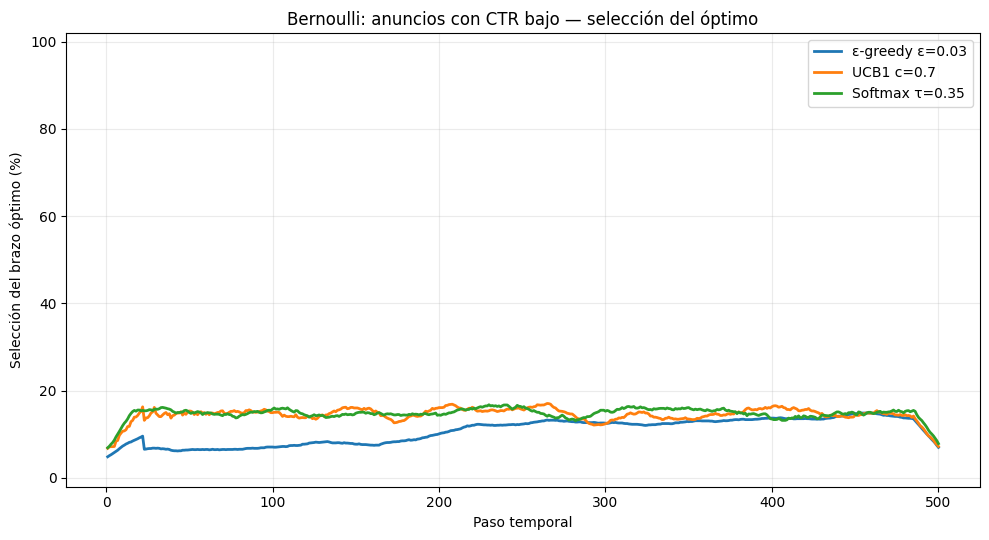

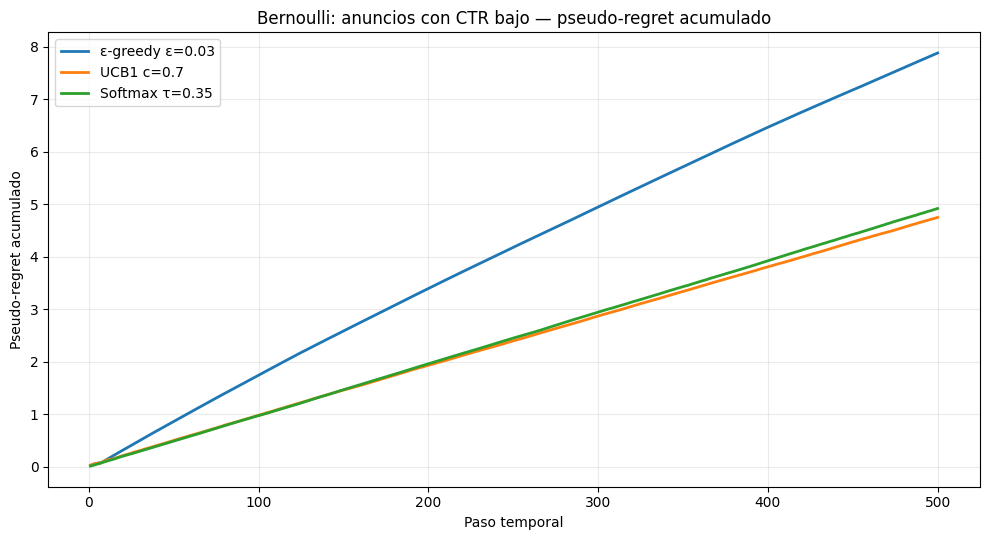

## Binomial: promociones por lotes

La escala de recompensa es mayor y la varianza depende de p; sirve para observar sensibilidad a la escala.

```text
Bandit with 7 arms: ArmBinomial(n=80, p=0.085), ArmBinomial(n=80, p=0.115), ArmBinomial(n=80, p=0.135), ArmBinomial(n=80, p=0.158), ArmBinomial(n=80, p=0.176), ArmBinomial(n=80, p=0.19), ArmBinomial(n=80, p=0.202)

Resumen de medias reales usadas solo para evaluación:
  brazo 0: E[r]=6.8000, gap=9.3600
  brazo 1: E[r]=9.2000, gap=6.9600
  brazo 2: E[r]=10.8000, gap=5.3600
  brazo 3: E[r]=12.6400, gap=3.5200
  brazo 4: E[r]=14.0800, gap=2.0800
  brazo 5: E[r]=15.2000, gap=0.9600
  brazo 6: E[r]=16.1600, gap=0.0000 <- óptimo
```

,algoritmo,recompensa_media_total,recompensa_media_último_20%,regret_final,% óptimo_final,% óptimo_último_20%,% tiradas_brazo_óptimo
0,ε-greedy ε=0.03,15.7195,15.8723,246.9568,70.6667,74.6400,68.3253
1,UCB1 c=0.7,15.6403,15.7171,253.0880,65.3333,65.3200,62.2773
2,Softmax τ=0.35,11.8993,11.8985,2122.6667,13.3333,13.3333,13.3333


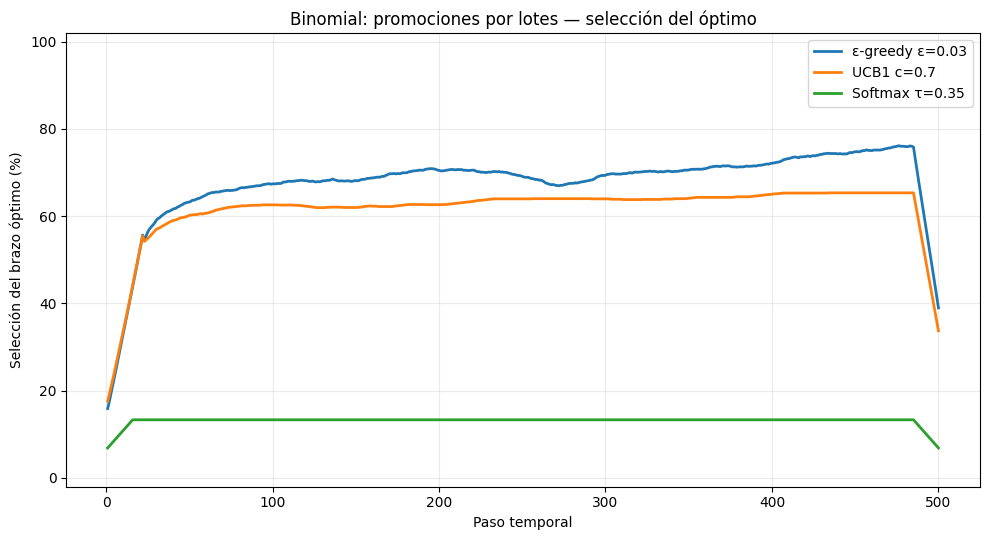

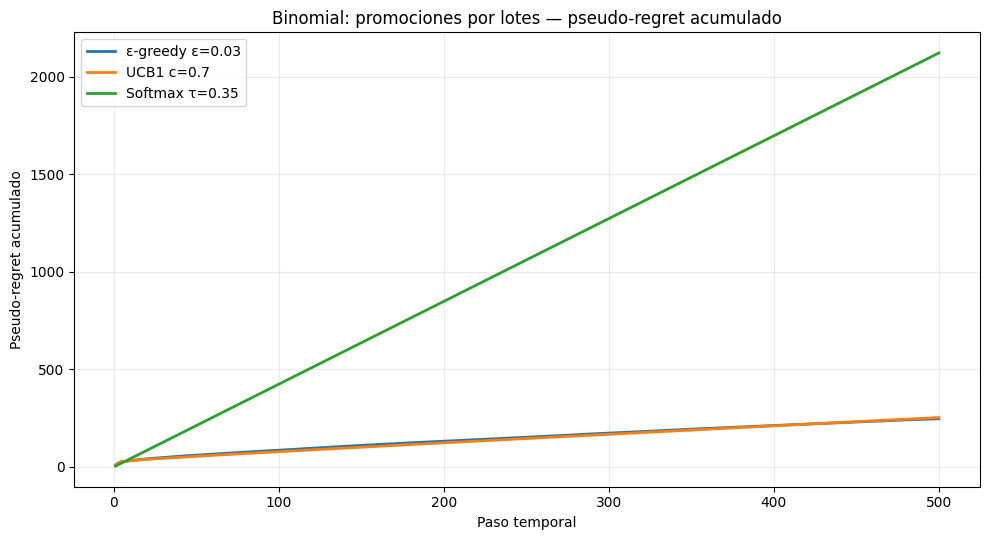

## Normal: recomendadores de watch-time

Permite recompensas continuas y ruido heterocedástico; el brazo más variable no siempre es el mejor.

```text
Bandit with 7 arms: ArmNormal(mu=4.4, sigma=1.7), ArmNormal(mu=5.0, sigma=2.8), ArmNormal(mu=5.4, sigma=1.2), ArmNormal(mu=5.7, sigma=4.0), ArmNormal(mu=6.1, sigma=1.0), ArmNormal(mu=6.25, sigma=3.2), ArmNormal(mu=6.55, sigma=1.5)

Resumen de medias reales usadas solo para evaluación:
  brazo 0: E[r]=4.4000, gap=2.1500
  brazo 1: E[r]=5.0000, gap=1.5500
  brazo 2: E[r]=5.4000, gap=1.1500
  brazo 3: E[r]=5.7000, gap=0.8500
  brazo 4: E[r]=6.1000, gap=0.4500
  brazo 5: E[r]=6.2500, gap=0.3000
  brazo 6: E[r]=6.5500, gap=0.0000 <- óptimo
```

,algoritmo,recompensa_media_total,recompensa_media_último_20%,regret_final,% óptimo_final,% óptimo_último_20%,% tiradas_brazo_óptimo
0,UCB1 c=0.7,6.4238,6.4810,64.4787,82.6667,82.1867,73.0667
1,ε-greedy ε=0.03,6.3560,6.3594,97.5400,68.0000,70.8667,64.7573
2,Softmax τ=0.35,5.7822,5.8097,380.3633,16.0000,16.0000,16.0000


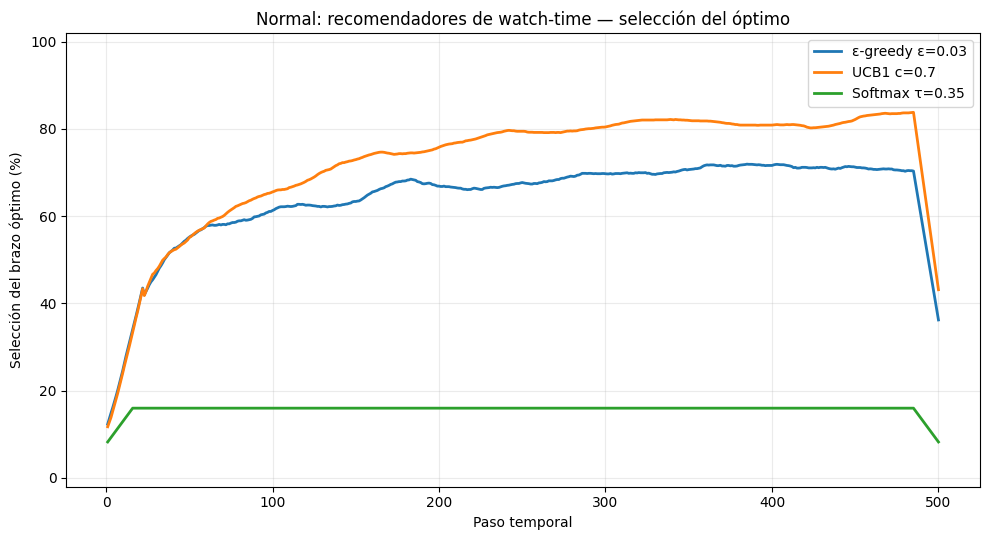

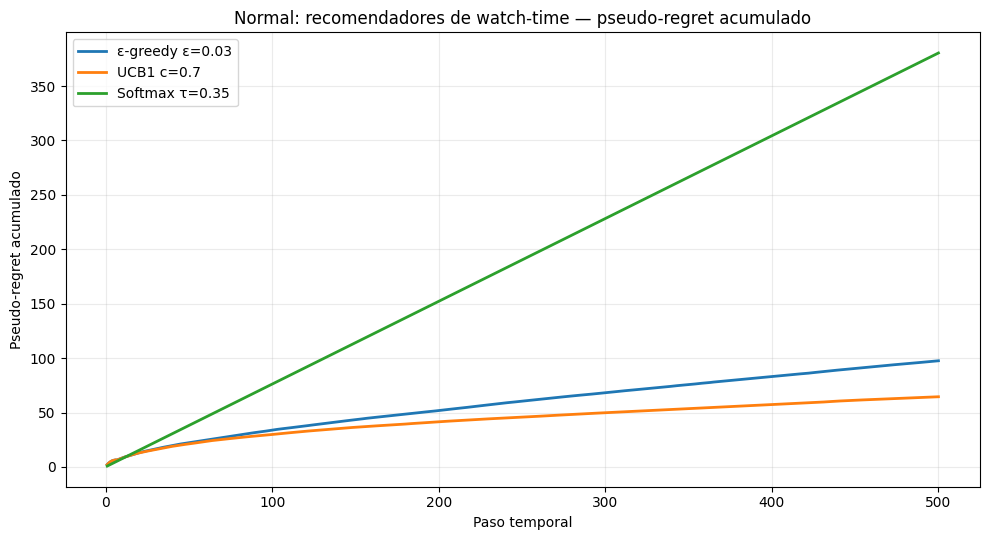

In [4]:
for key, spec in scenarios.items():
    display(Markdown(f"## {spec.title}\n\n{spec.rationale}\n\n```text\n{describe_bandit(spec.bandit)}\n```"))
    algorithms = algorithms_by_scenario[key]
    result = results[key]
    display(result[SUMMARY_NAME].round(4))
    plot_optimal_selections(STEPS, result[OPTIMAL_NAME], algorithms, f"{spec.title} — selección del óptimo", smooth_window=SMOOTH_WINDOW)
    plot_regret(STEPS, result[REGRET_NAME], algorithms, f"{spec.title} — pseudo-regret acumulado")

## Síntesis transversal

,escenario,algoritmo,recompensa_media_total,recompensa_media_último_20%,regret_final,% óptimo_final,% óptimo_último_20%,% tiradas_brazo_óptimo
0,Bernoulli: anuncios con CTR bajo,UCB1 c=0.7,0.0551,0.0536,4.7472,21.3333,14.6000,14.7147
1,Bernoulli: anuncios con CTR bajo,Softmax τ=0.35,0.0549,0.0549,4.9173,13.3333,14.7600,15.0000
2,Bernoulli: anuncios con CTR bajo,ε-greedy ε=0.03,0.0478,0.0461,7.8794,14.6667,13.9733,10.8827
3,Binomial: promociones por lotes,ε-greedy ε=0.03,15.7195,15.8723,246.9568,70.6667,74.6400,68.3253
4,Binomial: promociones por lotes,UCB1 c=0.7,15.6403,15.7171,253.0880,65.3333,65.3200,62.2773
5,Binomial: promociones por lotes,Softmax τ=0.35,11.8993,11.8985,2122.6667,13.3333,13.3333,13.3333
6,Normal: recomendadores de watch-time,UCB1 c=0.7,6.4238,6.4810,64.4787,82.6667,82.1867,73.0667
7,Normal: recomendadores de watch-time,ε-greedy ε=0.03,6.3560,6.3594,97.5400,68.0000,70.8667,64.7573
8,Normal: recomendadores de watch-time,Softmax τ=0.35,5.7822,5.8097,380.3633,16.0000,16.0000,16.0000


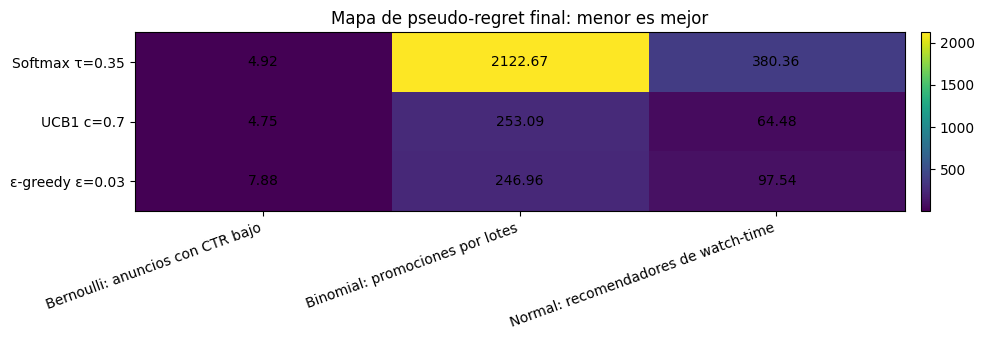

In [5]:
summary = BanditExperiment.collect_summaries(results, {k: s.title for k, s in scenarios.items()})
display(summary.round(4))
plot_summary_heatmap(summary, value="regret_final", title="Mapa de pseudo-regret final: menor es mejor")

## Conclusión técnica breve

La comparación transversal debe leerse como evidencia empírica condicionada por el diseño elegido. Si un algoritmo domina en un escenario y no en otro, eso no es una contradicción: el dilema exploración-explotación depende de la escala, el ruido y las brechas entre brazos. En la documentación escrita conviene seleccionar solo los resultados más informativos y justificar por qué responden a la pregunta experimental planteada.